In [1]:
import pandas as pd
import numpy as np

c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("Zone_Hour_Demand.csv")
df

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations
0,Mumbai,1,0,177,6
1,Mumbai,1,1,133,13
2,Mumbai,1,2,96,15
3,Mumbai,1,3,94,16
4,Mumbai,1,4,180,5
...,...,...,...,...,...
955,Hyderabad,10,19,129,37
956,Hyderabad,10,20,178,38
957,Hyderabad,10,21,33,7
958,Hyderabad,10,22,185,13


In [3]:
# Calculate hourly averages for ride requests and cancellations
hourly_ride_requests = df.groupby('Hour')['Avg_Ride_Requests'].mean()
hourly_cancellation = df.groupby('Hour')['Avg_Cancellations'].mean()

print("Hourly Ride Requests:")
print(hourly_ride_requests)
print("\nHourly Cancellations:")
print(hourly_cancellation)

Hourly Ride Requests:
Hour
0     109.300
1     105.150
2     106.550
3     104.100
4     106.400
5     115.425
6     118.725
7     118.000
8     122.000
9     113.475
10     99.275
11    106.400
12    115.900
13    113.600
14    119.850
15    109.300
16    114.575
17    125.675
18    111.925
19    112.200
20    125.400
21    122.550
22    108.250
23    108.825
Name: Avg_Ride_Requests, dtype: float64

Hourly Cancellations:
Hour
0     19.325
1     21.825
2     21.075
3     21.000
4     22.700
5     21.925
6     21.125
7     21.975
8     20.925
9     22.175
10    19.450
11    20.275
12    20.675
13    21.575
14    21.900
15    21.150
16    18.525
17    20.075
18    24.500
19    22.825
20    22.075
21    22.075
22    20.775
23    18.825
Name: Avg_Cancellations, dtype: float64


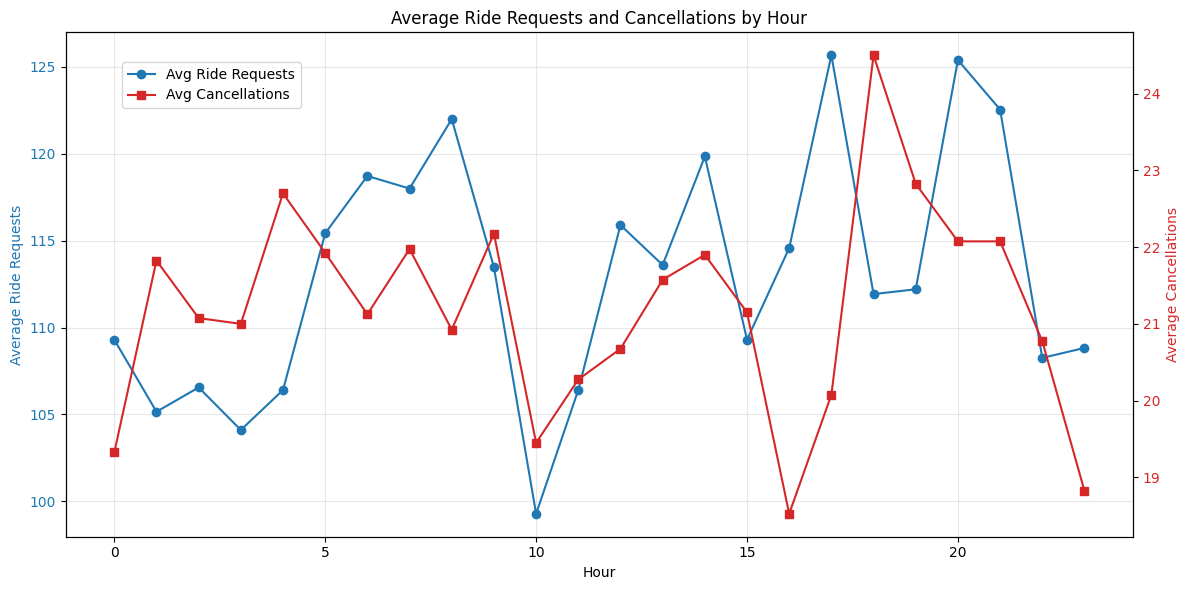

In [4]:
import matplotlib.pyplot as plt

# Create a single plot with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot hourly ride requests on the left y-axis
color = 'tab:blue'
ax1.set_xlabel('Hour')
ax1.set_ylabel('Average Ride Requests', color=color)
ax1.plot(hourly_ride_requests.index, hourly_ride_requests.values, color=color, marker='o', label='Avg Ride Requests')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Create a second y-axis for cancellations
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Average Cancellations', color=color)
ax2.plot(hourly_cancellation.index, hourly_cancellation.values, color=color, marker='s', label='Avg Cancellations')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Average Ride Requests and Cancellations by Hour')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

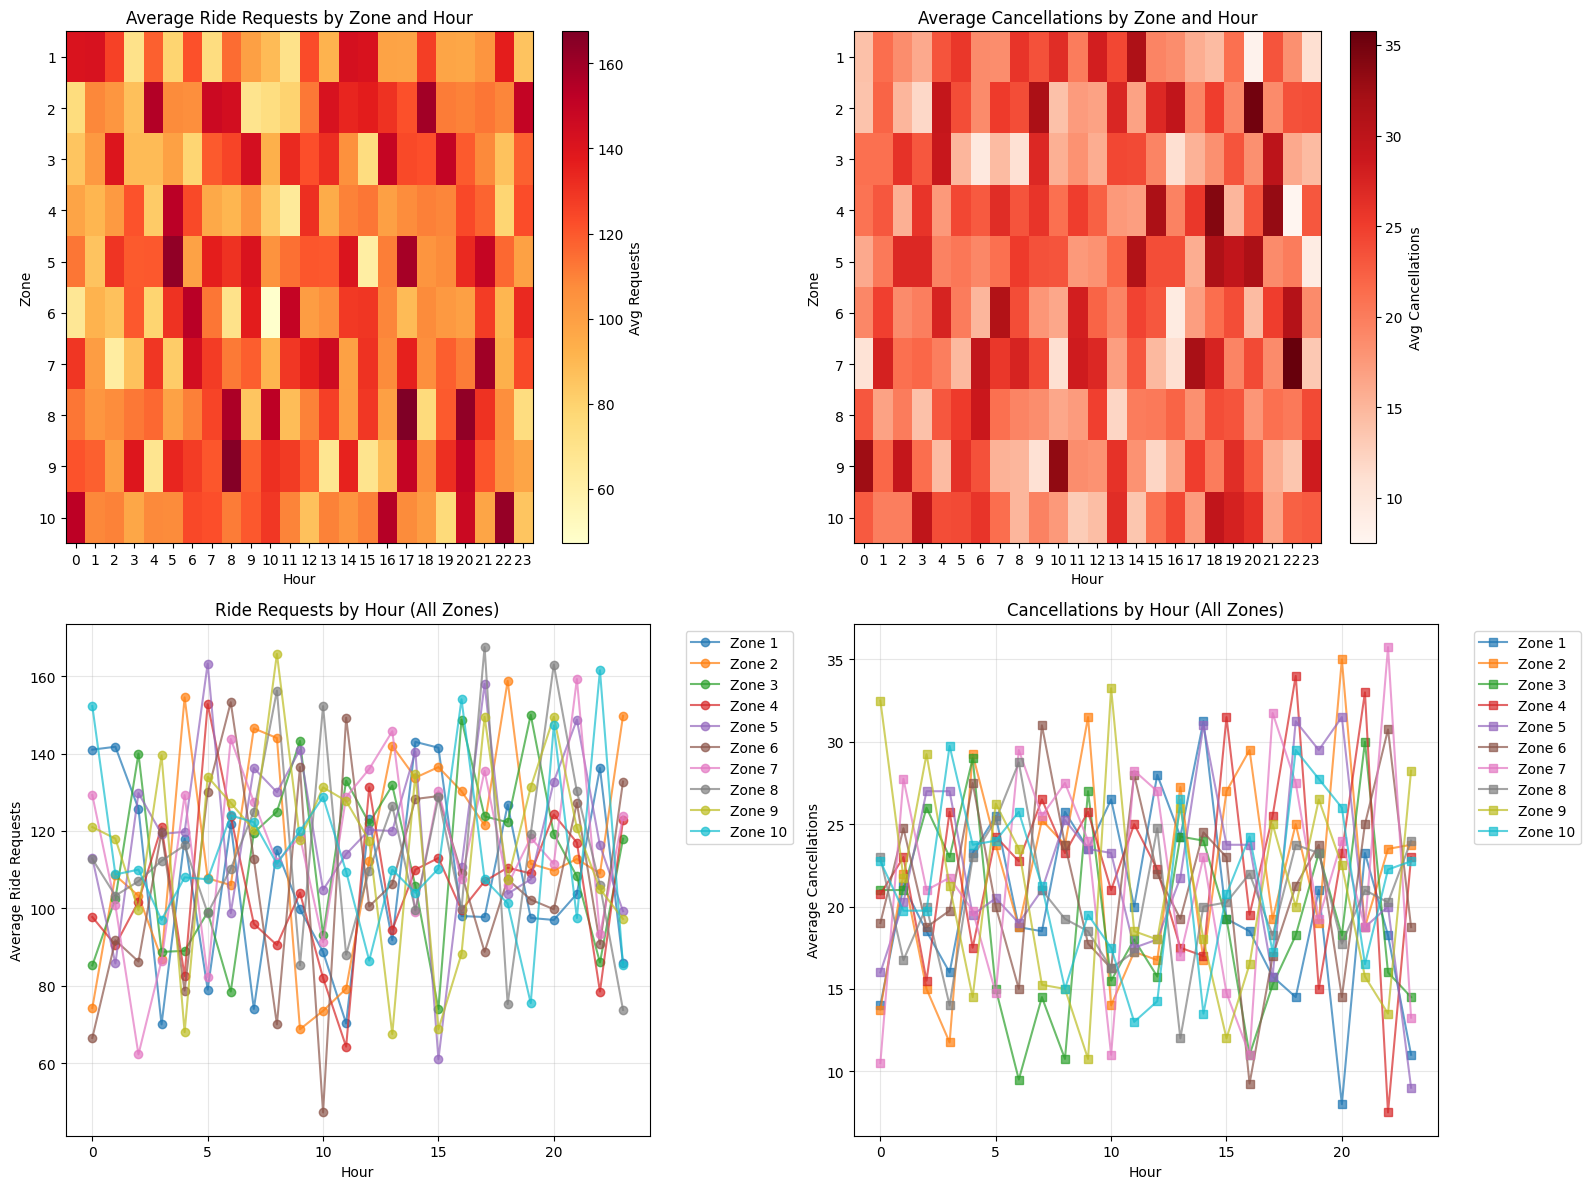

Zone-Hour Analysis Summary:
             Zone        Hour  Avg_Ride_Requests  Avg_Cancellations
count  240.000000  240.000000         240.000000         240.000000
mean     5.500000   11.500000         113.035417          21.197917
std      2.878284    6.936653          23.861521           5.643191
min      1.000000    0.000000          47.250000           7.500000
25%      3.000000    5.750000          97.937500          17.250000
50%      5.500000   11.500000         111.750000          21.000000
75%      8.000000   17.250000         129.250000          25.000000
max     10.000000   23.000000         167.500000          35.750000


In [5]:
# Calculate hourly averages by zone
hourly_zone_analysis = df.groupby(['Zone', 'Hour']).agg({
    'Avg_Ride_Requests': 'mean',
    'Avg_Cancellations': 'mean'
}).reset_index()

# Create visualizations for zone-hour patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Heatmap of Average Ride Requests by Zone and Hour
pivot_requests = hourly_zone_analysis.pivot(index='Zone', columns='Hour', values='Avg_Ride_Requests')
im1 = axes[0, 0].imshow(pivot_requests, aspect='auto', cmap='YlOrRd')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Zone')
axes[0, 0].set_title('Average Ride Requests by Zone and Hour')
axes[0, 0].set_xticks(range(24))
axes[0, 0].set_yticks(range(len(pivot_requests)))
axes[0, 0].set_yticklabels(pivot_requests.index)
plt.colorbar(im1, ax=axes[0, 0], label='Avg Requests')

# Plot 2: Heatmap of Average Cancellations by Zone and Hour
pivot_cancellations = hourly_zone_analysis.pivot(index='Zone', columns='Hour', values='Avg_Cancellations')
im2 = axes[0, 1].imshow(pivot_cancellations, aspect='auto', cmap='Reds')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Zone')
axes[0, 1].set_title('Average Cancellations by Zone and Hour')
axes[0, 1].set_xticks(range(24))
axes[0, 1].set_yticks(range(len(pivot_cancellations)))
axes[0, 1].set_yticklabels(pivot_cancellations.index)
plt.colorbar(im2, ax=axes[0, 1], label='Avg Cancellations')

# Plot 3: Line plot of requests by hour for each zone
for zone_id in df['Zone'].unique():
    zone_hourly = hourly_zone_analysis[hourly_zone_analysis['Zone'] == zone_id]
    axes[1, 0].plot(zone_hourly['Hour'], zone_hourly['Avg_Ride_Requests'], 
                    marker='o', label=f'Zone {zone_id}', alpha=0.7)
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Average Ride Requests')
axes[1, 0].set_title('Ride Requests by Hour (All Zones)')
axes[1, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Line plot of cancellations by hour for each zone
for zone_id in df['Zone'].unique():
    zone_hourly = hourly_zone_analysis[hourly_zone_analysis['Zone'] == zone_id]
    axes[1, 1].plot(zone_hourly['Hour'], zone_hourly['Avg_Cancellations'], 
                    marker='s', label=f'Zone {zone_id}', alpha=0.7)
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Average Cancellations')
axes[1, 1].set_title('Cancellations by Hour (All Zones)')
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Zone-Hour Analysis Summary:")
print(hourly_zone_analysis.describe())

In [6]:
# Group by Zone and Hour to analyze patterns
zone_hour_analysis = df.groupby(['Zone', 'Hour']).agg({
    'Avg_Ride_Requests': 'mean',
    'Avg_Cancellations': 'mean'
}).reset_index()

# Calculate correlation by zone
zone_correlations = []
for zone in df['Zone'].unique():
    zone_data = df[df['Zone'] == zone]
    corr = zone_data['Avg_Ride_Requests'].corr(zone_data['Avg_Cancellations'])
    zone_correlations.append({'Zone': zone, 'Correlation': corr})

zone_corr_df = pd.DataFrame(zone_correlations)

# Find peak hours by zone
peak_by_zone = df.groupby('Zone').apply(
    lambda x: pd.Series({
        'Peak_Request_Hour': x.loc[x['Avg_Ride_Requests'].idxmax(), 'Hour'],
        'Max_Requests': x['Avg_Ride_Requests'].max(),
        'Peak_Cancellation_Hour': x.loc[x['Avg_Cancellations'].idxmax(), 'Hour'],
        'Max_Cancellations': x['Avg_Cancellations'].max()
    })
).reset_index()

print("Zone-wise Correlation between Requests and Cancellations:")
print(zone_corr_df)
print("\n" + "="*70 + "\n")
print("Peak Hours by Zone:")
print(peak_by_zone)
print("\n" + "="*70 + "\n")
print("Zone-Hour Analysis (Sample):")
print(zone_hour_analysis.head(10))

Zone-wise Correlation between Requests and Cancellations:
   Zone  Correlation
0     1    -0.040453
1     2     0.150289
2     3    -0.077976
3     4     0.060877
4     5     0.029624
5     6    -0.052441
6     7    -0.018305
7     8    -0.027127
8     9     0.022589
9    10     0.190384


Peak Hours by Zone:
   Zone  Peak_Request_Hour  Max_Requests  Peak_Cancellation_Hour  \
0     1                 21           199                       5   
1     2                 13           199                      16   
2     3                  8           198                      20   
3     4                 23           197                       7   
4     5                 20           199                       2   
5     6                 23           196                      22   
6     7                 21           193                       2   
7     8                 20           199                       0   
8     9                  3           199                      17   
9    10  

In [7]:
df

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations
0,Mumbai,1,0,177,6
1,Mumbai,1,1,133,13
2,Mumbai,1,2,96,15
3,Mumbai,1,3,94,16
4,Mumbai,1,4,180,5
...,...,...,...,...,...
955,Hyderabad,10,19,129,37
956,Hyderabad,10,20,178,38
957,Hyderabad,10,21,33,7
958,Hyderabad,10,22,185,13


City-wise Contribution Analysis:
           Total_Requests  Avg_Requests  Total_Cancellations  \
City                                                           
Bengaluru           26636        110.98                 4990   
Delhi               26971        112.38                 5109   
Hyderabad           27284        113.68                 5132   
Mumbai              27623        115.10                 5119   

           Avg_Cancellations  Cancellation_Rate_%  
City                                               
Bengaluru              20.79                18.73  
Delhi                  21.29                18.94  
Hyderabad              21.38                18.81  
Mumbai                 21.33                18.53  




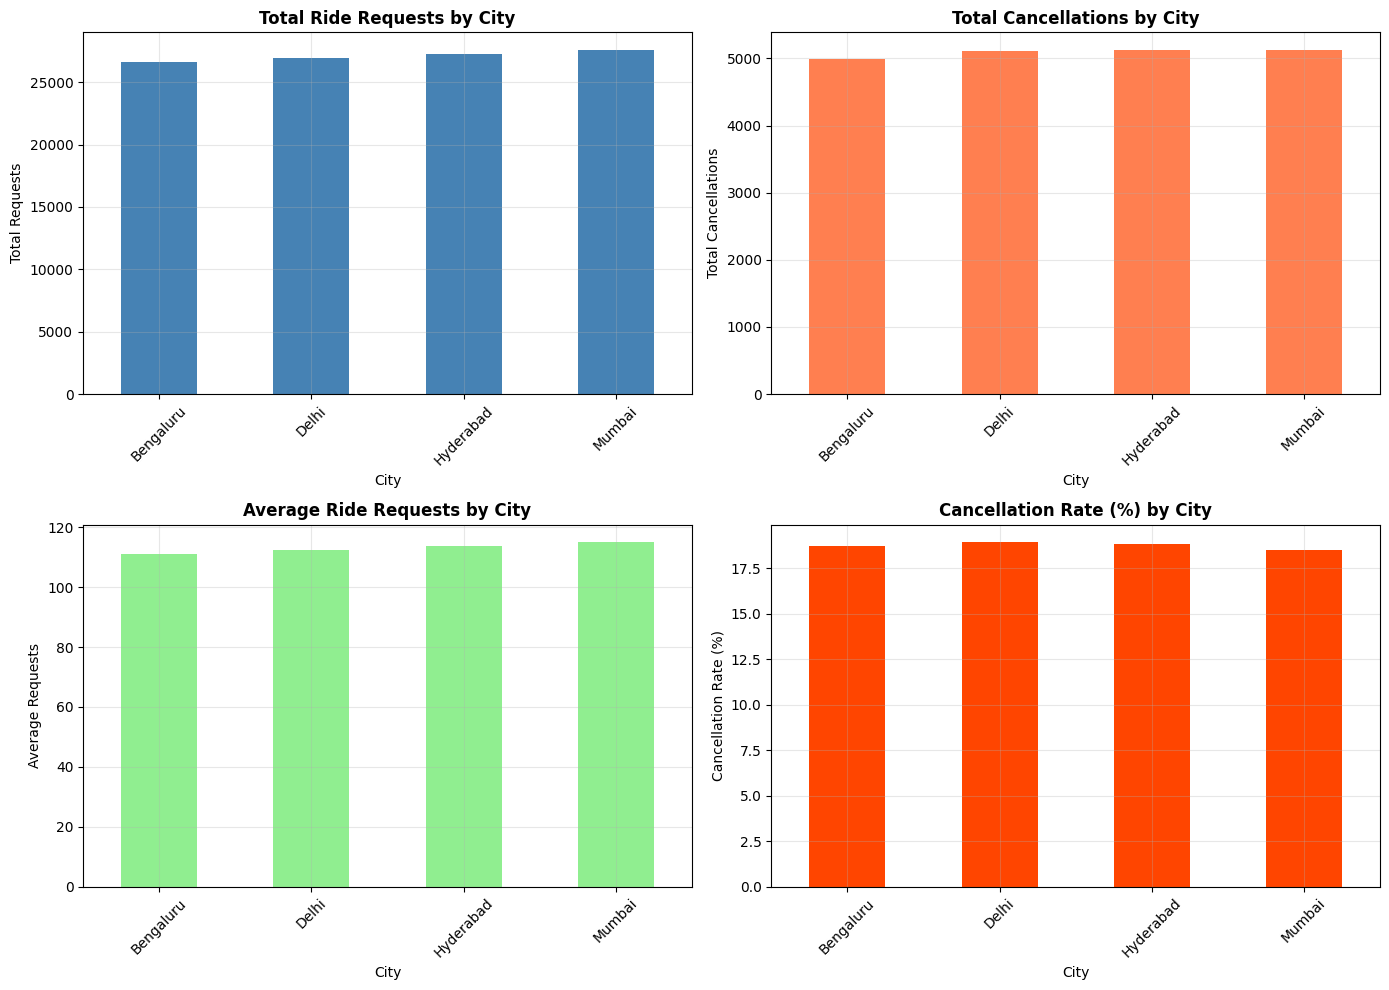

KEY INSIGHTS - CITY-WISE ANALYSIS:

• City with Highest Total Requests: Mumbai (27623)
• City with Highest Total Cancellations: Hyderabad (5132)
• City with Highest Cancellation Rate: Delhi (18.94%)
• City with Lowest Cancellation Rate: Mumbai (18.53%)
• Average Cancellation Rate Across Cities: 18.75%


In [8]:
# Calculate city-wise contribution
city_contribution = df.groupby('City').agg({
    'Avg_Ride_Requests': ['sum', 'mean'],
    'Avg_Cancellations': ['sum', 'mean']
}).round(2)

city_contribution.columns = ['Total_Requests', 'Avg_Requests', 'Total_Cancellations', 'Avg_Cancellations']
city_contribution['Cancellation_Rate_%'] = (city_contribution['Total_Cancellations'] / city_contribution['Total_Requests'] * 100).round(2)

print("City-wise Contribution Analysis:")
print(city_contribution)
print("\n" + "="*70 + "\n")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Total Requests by City
city_contribution['Total_Requests'].plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Total Ride Requests by City', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Total Requests')
axes[0, 0].set_xlabel('City')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Total Cancellations by City
city_contribution['Total_Cancellations'].plot(kind='bar', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Total Cancellations by City', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Cancellations')
axes[0, 1].set_xlabel('City')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Average Requests by City
city_contribution['Avg_Requests'].plot(kind='bar', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Average Ride Requests by City', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Average Requests')
axes[1, 0].set_xlabel('City')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cancellation Rate by City
city_contribution['Cancellation_Rate_%'].plot(kind='bar', ax=axes[1, 1], color='orangered')
axes[1, 1].set_title('Cancellation Rate (%) by City', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Cancellation Rate (%)')
axes[1, 1].set_xlabel('City')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Key Insights
print("KEY INSIGHTS - CITY-WISE ANALYSIS:\n")
print(f"• City with Highest Total Requests: {city_contribution['Total_Requests'].idxmax()} ({city_contribution['Total_Requests'].max():.0f})")
print(f"• City with Highest Total Cancellations: {city_contribution['Total_Cancellations'].idxmax()} ({city_contribution['Total_Cancellations'].max():.0f})")
print(f"• City with Highest Cancellation Rate: {city_contribution['Cancellation_Rate_%'].idxmax()} ({city_contribution['Cancellation_Rate_%'].max():.2f}%)")
print(f"• City with Lowest Cancellation Rate: {city_contribution['Cancellation_Rate_%'].idxmin()} ({city_contribution['Cancellation_Rate_%'].min():.2f}%)")
print(f"• Average Cancellation Rate Across Cities: {city_contribution['Cancellation_Rate_%'].mean():.2f}%")

In [9]:
df

,City,Zone,Hour,Avg_Ride_Requests,Avg_Cancellations
0,Mumbai,1,0,177,6
1,Mumbai,1,1,133,13
2,Mumbai,1,2,96,15
3,Mumbai,1,3,94,16
4,Mumbai,1,4,180,5
...,...,...,...,...,...
955,Hyderabad,10,19,129,37
956,Hyderabad,10,20,178,38
957,Hyderabad,10,21,33,7
958,Hyderabad,10,22,185,13


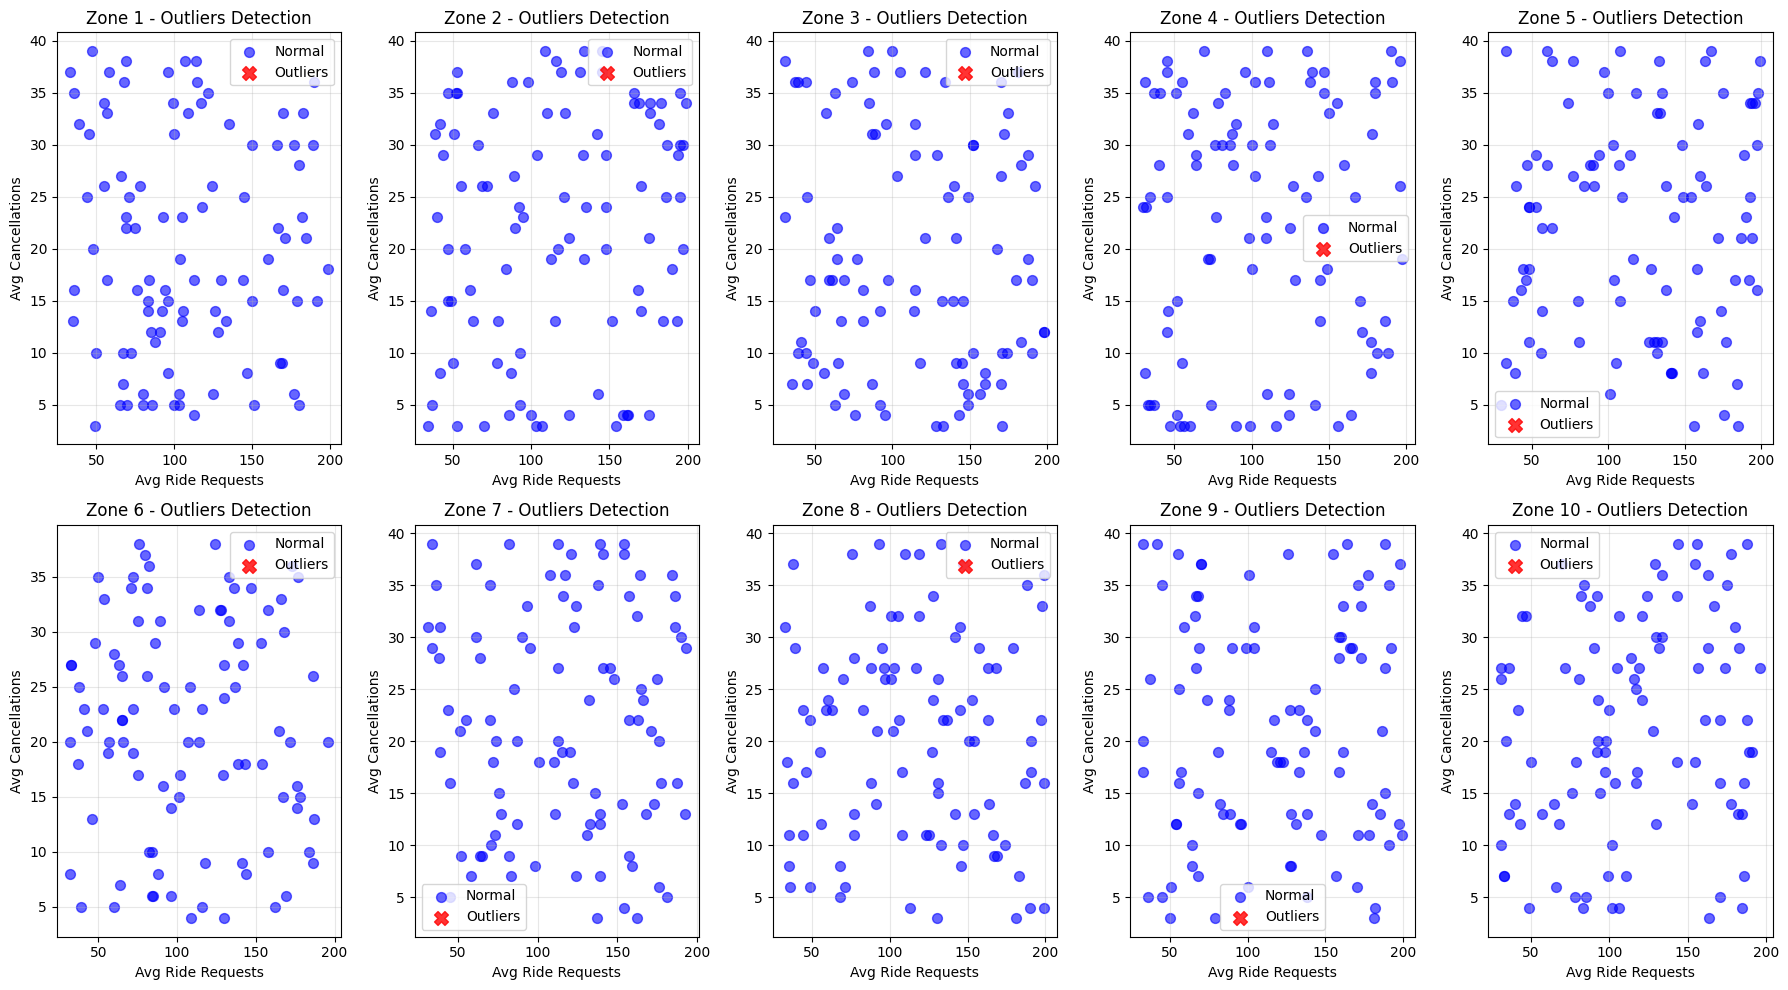

OUTLIERS SUMMARY BY ZONE:
No outliers detected using IQR method (1.5x)


In [10]:
# Find outliers using IQR method for each zone
outliers_data = []

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for idx, zone in enumerate(sorted(df['Zone'].unique())):
    zone_data = df[df['Zone'] == zone]
    
    # Calculate IQR for Ride Requests
    Q1_requests = zone_data['Avg_Ride_Requests'].quantile(0.25)
    Q3_requests = zone_data['Avg_Ride_Requests'].quantile(0.75)
    IQR_requests = Q3_requests - Q1_requests
    
    # Calculate IQR for Cancellations
    Q1_cancel = zone_data['Avg_Cancellations'].quantile(0.25)
    Q3_cancel = zone_data['Avg_Cancellations'].quantile(0.75)
    IQR_cancel = Q3_cancel - Q1_cancel
    
    # Identify outliers
    outlier_mask = ((zone_data['Avg_Ride_Requests'] < Q1_requests - 1.5*IQR_requests) | 
                    (zone_data['Avg_Ride_Requests'] > Q3_requests + 1.5*IQR_requests) |
                    (zone_data['Avg_Cancellations'] < Q1_cancel - 1.5*IQR_cancel) | 
                    (zone_data['Avg_Cancellations'] > Q3_cancel + 1.5*IQR_cancel))
    
    outliers = zone_data[outlier_mask]
    outliers_data.append(outliers)
    
    # Plot
    ax = axes[idx]
    ax.scatter(zone_data['Avg_Ride_Requests'], zone_data['Avg_Cancellations'], 
               alpha=0.6, s=50, color='blue', label='Normal')
    ax.scatter(outliers['Avg_Ride_Requests'], outliers['Avg_Cancellations'], 
               alpha=0.8, s=100, color='red', marker='X', label='Outliers')
    ax.set_xlabel('Avg Ride Requests')
    ax.set_ylabel('Avg Cancellations')
    ax.set_title(f'Zone {zone} - Outliers Detection')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display outliers summary
print("OUTLIERS SUMMARY BY ZONE:\n" + "="*70)
all_outliers = pd.concat(outliers_data, ignore_index=True)
if len(all_outliers) > 0:
    print(all_outliers.sort_values(['Zone', 'Hour']))
    print(f"\nTotal Outliers Found: {len(all_outliers)}")
else:
    print("No outliers detected using IQR method (1.5x)")